In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

# import cuml
# cuml.accel.install()
# %load_ext cudf.pandas

ℹ️ Device: CPU 4 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.calibration import CalibrationDisplay

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

import warnings

2026-03-18 13:05:28.772180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773839129.082540      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773839129.173002      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773839129.951810      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773839129.951855      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773839129.951857      17 computation_placer.cc:177] computation placer alr

In [3]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']] 
BASE   = NUMS + CATS

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16
Total base features: 19


In [5]:
display(train.head())
train.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [6]:
train[NUMS].describe()

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


In [7]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


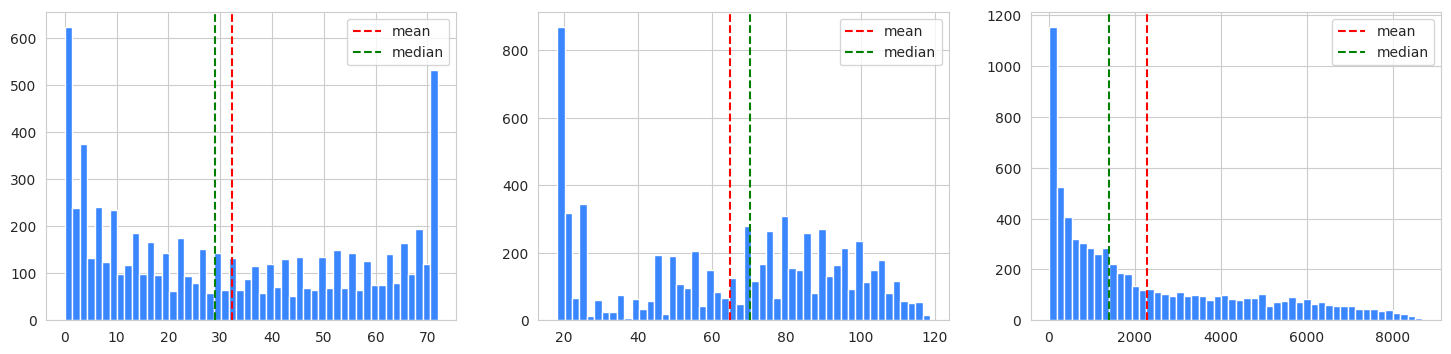

In [8]:
plt.figure(figsize=(18, 4))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.legend()

plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


# FEATURE ENGINEERING

In [10]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []

In [11]:
print(f"\nEXTRACTING ROUNDS... ", end='')
for col in ['TotalCharges']:
    for r in [-3, -2, -1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nCREATING E_BINS... ", end='')
    for b in [400]: # 100, 500, 1000
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [1000]: # 100, 500, 1000
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)
        
print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")


EXTRACTING ROUNDS... TotalCharges_round_-3, TotalCharges_round_-2, TotalCharges_round_-1, TotalCharges_round_0, TotalCharges_round_1, 
EXTRACTING DIGITS... TotalCharges_digit_-3, TotalCharges_digit_-2, TotalCharges_digit_-1, TotalCharges_digit_0, TotalCharges_digit_1, TotalCharges_digit_2, 
CREATING E_BINS... TotalCharges_bin_400, 
QUANTILE BINNING... TotalCharges_Qbin_1000, 
✅ TOTAL ROUND FEATURES: 5
✅ TOTAL DIGITS EXTRACTED: 6
✅ TOTAL EQUAL E_BINS: 1
✅ TOTAL QUANTILE E_BINS: 1


In [12]:
for col in ['MonthlyCharges']:
    print(f"\nROUNDING FEATURES... ", end='')
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)
            
    print(f"\nEQUAL BINNING... ", end='')
    for b in [100]: # 50, 100, 400
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)
        
    print(f"\nQUANTILE BINNING... ", end='')
    for q in [500]: # 50, 100, 400
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")


ROUNDING FEATURES... MonthlyCharges_round_-2, MonthlyCharges_round_-1, MonthlyCharges_round_0, 
EXTRACTING DIGITS... MonthlyCharges_digit_-2, MonthlyCharges_digit_-1, MonthlyCharges_digit_0, MonthlyCharges_digit_1, MonthlyCharges_digit_2, 
EQUAL BINNING... MonthlyCharges_bin_100, 
QUANTILE BINNING... MonthlyCharges_Qbin_500, 
✅ TOTAL DIGITS: 11
✅ TOTAL ROUNDs: 7
✅ TOTAL EQUAL BINS: 2
✅ TOTAL QUANTILE BINS: 2


In [13]:
for col in ['tenure']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    # print()
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-1, 0]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nEQUAL BINNING... ", end='')
    for b in [10, 50]: # 10, 50
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [10, 50]: # 10, 50
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING ROUNDS... tenure_round_-1, 
EXTRACTING DIGITS... tenure_digit_-1, tenure_digit_0, 
EQUAL BINNING... tenure_bin_10, tenure_bin_50, 
QUANTILE BINNING... tenure_Qbin_10, tenure_Qbin_50, 
✅ TOTAL ROUND FEATURES: 8         
✅ TOTAL DIGITS FEATURES: 13        
✅ TOTAL EQUAL BINS: 4         
✅ TOTAL QUANTILE BINS: 4         


In [14]:
ALL_ROUND_BINS = ROUNDS + E_BINS + Q_BINS

train[ALL_ROUND_BINS].nunique().sort_values() #.index[:9].tolist()

tenure_round_-1               8
TotalCharges_round_-3        10
tenure_Qbin_10               10
tenure_bin_10                10
MonthlyCharges_round_-1      11
tenure_Qbin_50               42
tenure_bin_50                50
TotalCharges_round_-2        88
MonthlyCharges_bin_100      100
MonthlyCharges_round_0      102
TotalCharges_bin_400        396
MonthlyCharges_Qbin_500     433
TotalCharges_round_-1       846
TotalCharges_Qbin_1000      998
TotalCharges_round_1       5298
TotalCharges_round_0       5785
dtype: int64

In [15]:
LOW_100_UNIQUE = []
LOW_100_UNIQUE.append('cat_tenure')

for col in ALL_ROUND_BINS:
    if train[col].nunique() < 100:
        LOW_100_UNIQUE.append(col)

print(f"Cats with ~100 unique: {len(LOW_100_UNIQUE)}")
print()
TOP_100_UNIQUE = [c for c in ALL_ROUND_BINS if c not in LOW_100_UNIQUE]
print(f"Cats with 100+ unique: {len(TOP_100_UNIQUE)}")

Cats with ~100 unique: 9

Cats with 100+ unique: 8


In [16]:
train[TOP_100_UNIQUE].nunique()

TotalCharges_round_-1       846
TotalCharges_round_0       5785
TotalCharges_round_1       5298
MonthlyCharges_round_0      102
TotalCharges_bin_400        396
MonthlyCharges_bin_100      100
TotalCharges_Qbin_1000      998
MonthlyCharges_Qbin_500     433
dtype: int64

In [17]:
# ## -- Arithmetic interaction --
# for df in [train, test, orig]:
#     df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
#     df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
#     df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

# arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
#               '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

# train[arithmetic].head()

In [18]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [19]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_FREQ'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)
    
# print()
# print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")

In [20]:
# INTER = []
# TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

# for c1, c2 in tqdm(list(itertools.combinations(TOP_CATS+DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_CATS[:4], 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='One-To-Many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

# print(f"TOTAL INTERACTION FEATURES: {len(INTER)}")

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [22]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [23]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features=BASE,
    target=TARGET,
    aggs=['mean'],
    # mean, median, count, std, skew, nunique, max, min
    fill_nan=True,
)

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

In [24]:
# ## -- DUPLICATE 'tunure' AS CATEGORICAL --
# for df in [train, test, orig]:
#     df['cat_tenure'] = df['tenure'].values

In [25]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 67


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_400,TotalCharges_Qbin_1000,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_round_-1,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_Qbin_10,tenure_Qbin_50,OTE_tenure_mean,OTE_MonthlyCharges_mean,OTE_TotalCharges_mean,OTE_gender_mean,OTE_SeniorCitizen_mean,OTE_Partner_mean,OTE_Dependents_mean,OTE_PhoneService_mean,OTE_MultipleLines_mean,OTE_InternetService_mean,OTE_OnlineSecurity_mean,OTE_OnlineBackup_mean,OTE_DeviceProtection_mean,OTE_TechSupport_mean,OTE_StreamingTV_mean,OTE_StreamingMovies_mean,OTE_Contract_mean,OTE_PaperlessBilling_mean,OTE_PaymentMethod_mean
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0,2000,1700,1650,1654,1653,1,6,5,3,8,5,75,538,60,60,0,6,0,1,0,41,133,30,2,9,3,19,4,19,0.208333,1.000000,0.0,0.261603,0.236062,0.196649,0.154502,0.267096,0.250442,0.189591,0.146112,0.399288,0.225021,0.151663,0.335231,0.336804,0.112695,0.335651,0.191067
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0,4000,3800,3780,3778,3778,3,7,7,8,2,0,173,716,70,70,0,6,9,5,0,50,159,60,5,8,8,40,7,32,0.164179,0.272727,0.0,0.261603,0.236062,0.196649,0.154502,0.267096,0.250442,0.189591,0.146112,0.215315,0.391276,0.151663,0.300702,0.336804,0.028319,0.163301,0.152431
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0,6000,5800,5840,5841,5841,5,8,4,1,3,5,268,863,100,100,1,0,0,4,0,81,366,60,5,8,8,40,7,32,0.164179,0.000000,0.0,0.261603,0.236062,0.196649,0.312791,0.267096,0.286099,0.418928,0.417667,0.215315,0.391276,0.416355,0.300702,0.299414,0.427097,0.335651,0.452854


# ML TRAINING

In [26]:
def Trainer_CV(
    model_name,
    params,
    train_df,
    test_df,
    features,
    target,
    kf,
    cats=None,
    one_hot_cats=None,
    drop='first',
    scaler_with_mean=True,
):

    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")
    start = time()
    
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n***** FOLD {idx+1}/{kf.n_splits} | ", end='')

        ## -- Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, nunique, max, min
        #     fill_nan=True,
        # )

        # cme_features = NUMS
        # cme_cols = []

        # print(f"CategoryMeanEncoding: {len(cme_features)} | ", end='')
        # for c in cme_features:
        #     n = f"CME_{c}"
        #     CME = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[n] = CME.fit_transform(X_train[[c]], y_train).fillna(-1)
        #     X_val[n]   = CME.transform(X_val[[c]]).fillna(-1)
        #     X_test[n]  = CME.transform(X_test[[c]]).fillna(-1)
        #     cme_cols.append(n)

        ## -- TE Opt1. -> Using CUSTOM --
        TE = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        X_train = TE.fit_transform(X_train, y_train).fillna(0)
        X_val = TE.transform(X_val).fillna(0)
        X_test = TE.transform(X_test).fillna(0)

        ## -- TE Opt1. -> Using CUSTOM --
        TE = TargetEncoder(ALL_ROUND_BINS+DIGITS, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, y_train).fillna(0)
        X_val = TE.transform(X_val).fillna(0)
        X_test = TE.transform(X_test).fillna(0)

        if 'log' in model_name:
            print(f"Train shape: {X_train.shape} *****")

            ## -- Create pipeline --
            model = make_pipeline(
                make_column_transformer(
                    (OneHotEncoder(
                        handle_unknown='ignore',
                        # sparse_output=False,
                        drop=drop,
                    ), one_hot_cats),
                    remainder='passthrough',
                    n_jobs=os.cpu_count(),
                ),
                StandardScaler() if scaler_with_mean else StandardScaler(with_mean=False),
                LogisticRegressionCV(**params),
            )
            model.fit(X_train, y_train)
        elif 'mlp' in model_name:
            print(f"X_train shape: {X_train.shape} *****")

            ## -- Create pipeline --
            model = make_pipeline(
                make_column_transformer(
                    (OneHotEncoder(
                        handle_unknown='ignore',
                        # sparse_output=False,
                        drop=drop,
                    ), one_hot_cats),
                    remainder='passthrough',
                    n_jobs=os.cpu_count(),
                ),
                StandardScaler() if scaler_with_mean else StandardScaler(with_mean=False),
                MLPClassifier(**params),
            )
            model.fit(X_train, y_train)
        elif 'rfc' in model_name:
            combined = pd.concat([X_train, X_val, X_test])
            if cats is not None:
                for col in cats:
                    combined[col] = combined[col].astype('category')
            else:
                pass

            X_train = combined.iloc[:len(X_train)]
            X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
            X_test  = combined.iloc[len(X_train)+len(X_val):]

            print(f"Train shape: {X_train.shape} #####")
            model = RandomForestClassifier(**params)
            model.fit(X_train, y_train)

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1].ravel()
        test_preds += model.predict_proba(X_test)[:, 1].ravel()

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'FOLD {idx+1} AUC: {fold_auc:.5f}')

        ## -- Clean up memory -- X_val
        del X_train, y_train, y_val, X_test
        gc.collect()

    ## -- Average the test predictions
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")

    for i, score in enumerate(fold_scores):
        print(f"Fold {i+1} AUC: {score:.5f}")

    ## -- Calculate and print the final out-of-fold AUC
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    if 'log' in model_name:
        print(f"Best Logistic 'C: {model[-1].C_}")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
        'val_data': X_val,
    }

print('===== ⚙️ Training function ready ⚙️ =====')

===== ⚙️ Training function ready ⚙️ =====


In [27]:
all_model_predictions = {}

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [28]:
## ========== LOGISTIC ============
if all_model_predictions:
    all_model_predictions.clear()

version_name = 'logV5'
M_NAME = f"{version_name}_"

PARAMS = {
    'max_iter': 2000,
    # 'Cs': N_SPLITS,
    'cv': 3,
    # 'C': 1.0,
    'scoring': 'neg_log_loss',
    'tol': 1e-5,
    'verbose': 0,
    'n_jobs': os.cpu_count(),
    'random_state': SEED,
}

for d in ['first', None]: # None, 'first'
    n = M_NAME + 'ohe_cats_' + str(d)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=CATS,
        one_hot_cats=CATS,
        drop=d,
        scaler_with_mean=False,
    )


==================== Starting Cross-Validation for logV5_ohe_cats_first ====================

***** FOLD 1/10 | Train shape: (534774, 70) *****
FOLD 1 AUC: 0.91489

***** FOLD 2/10 | Train shape: (534774, 70) *****
FOLD 2 AUC: 0.91419

***** FOLD 3/10 | Train shape: (534774, 70) *****
FOLD 3 AUC: 0.91690

***** FOLD 4/10 | Train shape: (534774, 70) *****
FOLD 4 AUC: 0.91453

***** FOLD 5/10 | Train shape: (534775, 70) *****
FOLD 5 AUC: 0.91462

***** FOLD 6/10 | Train shape: (534775, 70) *****
FOLD 6 AUC: 0.91545

***** FOLD 7/10 | Train shape: (534775, 70) *****
FOLD 7 AUC: 0.91660

***** FOLD 8/10 | Train shape: (534775, 70) *****
FOLD 8 AUC: 0.91541

***** FOLD 9/10 | Train shape: (534775, 70) *****
FOLD 9 AUC: 0.91389

***** FOLD 10/10 | Train shape: (534775, 70) *****
FOLD 10 AUC: 0.91278

Cross-Validation Results for logV5_ohe_cats_first
Fold 1 AUC: 0.91489
Fold 2 AUC: 0.91419
Fold 3 AUC: 0.91690
Fold 4 AUC: 0.91453
Fold 5 AUC: 0.91462
Fold 6 AUC: 0.91545
Fold 7 AUC: 0.91660
Fol

In [29]:
# ==================================================
# Cross-Validation Results for logV1_ohe_cats_None
# ==================================================
# Fold 1 AUC: 0.91627
# Fold 2 AUC: 0.91728
# Fold 3 AUC: 0.91667
# Fold 4 AUC: 0.91794
# Fold 5 AUC: 0.91479
# -------------------------------------------------|
# Overall AUC: 0.916588
# Average AUC: 0.916591 ± 0.001062
# -------------------------------------------------|
# Best Logistic 'C: [2.7825594]
# 54.57 mins

In [30]:
# ## ========== MLP ============
# version_name = 'MLPv1'
# M_NAME = f"{version_name}_"

# PARAMS = {
#     'max_iter': 1000,
#     'tol': 1e-5,
#     'random_state': SEED,
# }

# n = M_NAME + 'ohe_cats' + str(SEED)
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
#     one_hot_cats=CATS,
# )


# PARAMS['random_state'] = SEED_2
# n = M_NAME + 'ohe_cats_' + str(SEED_2)

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
#     one_hot_cats=CATS,
# )

# PARAMS['random_state'] = SEED_3
# n = M_NAME + 'ohe_cats_' + str(SEED_3)

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
#     one_hot_cats=CATS,
# )

In [31]:
## ========== RANDOM FOREST ============
# version_name = 'RFCv1'
# M_NAME = f"{version_name}_"

# ITERATIONS = 1000

# PARAMS = {
#     'n_estimators': ITERATIONS,
#     'criterion': 'gini', # gini, entropy, log_loss
#     'min_samples_leaf': 10,
#     'n_jobs': os.cpu_count(),
#     'random_state': SEED,
# }

# n = M_NAME + 'gini'
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
# )


# PARAMS['criterion'] = 'entropy'
# n = M_NAME + 'entropy'
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
# )


# PARAMS['criterion'] = 'log_loss'
# n = M_NAME + 'loss'
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
# )

# PARAMS['random_state'] = SEED_3
# n = M_NAME + 'loss' + str(SEED_3)

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
#     one_hot_cats=CATS,
# )

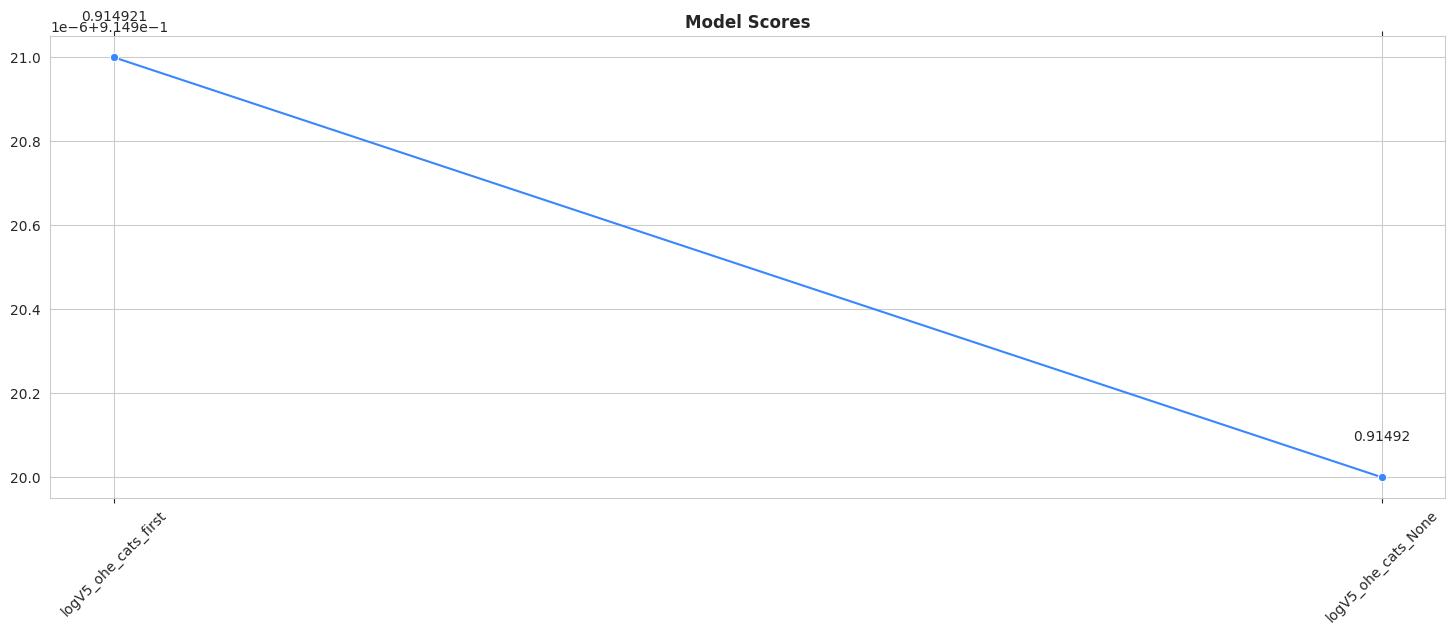

In [32]:
## -- Get models scores --
all_model_scores = {} 

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y

plt.figure(figsize=(18, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
plt.title('Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=45, reset=True)

for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+1e-7, score, ha='center', va='center_baseline')

plt.show()

In [33]:
## -- Get oof predictions --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}_models.parquet", index=False)
all_model_oof.head()

,logV5_ohe_cats_first_914921,logV5_ohe_cats_None_91492
0,0.010755,0.010752
1,0.001874,0.001894
2,0.391599,0.391542
3,0.880703,0.880540
4,0.881277,0.881106


In [34]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}_models.parquet", index=False)
all_model_test.head()

,logV5_ohe_cats_first_914921,logV5_ohe_cats_None_91492
0,0.070493,0.070412
1,0.001029,0.001033
2,0.129218,0.129070
3,0.003772,0.003780
4,0.511442,0.511539


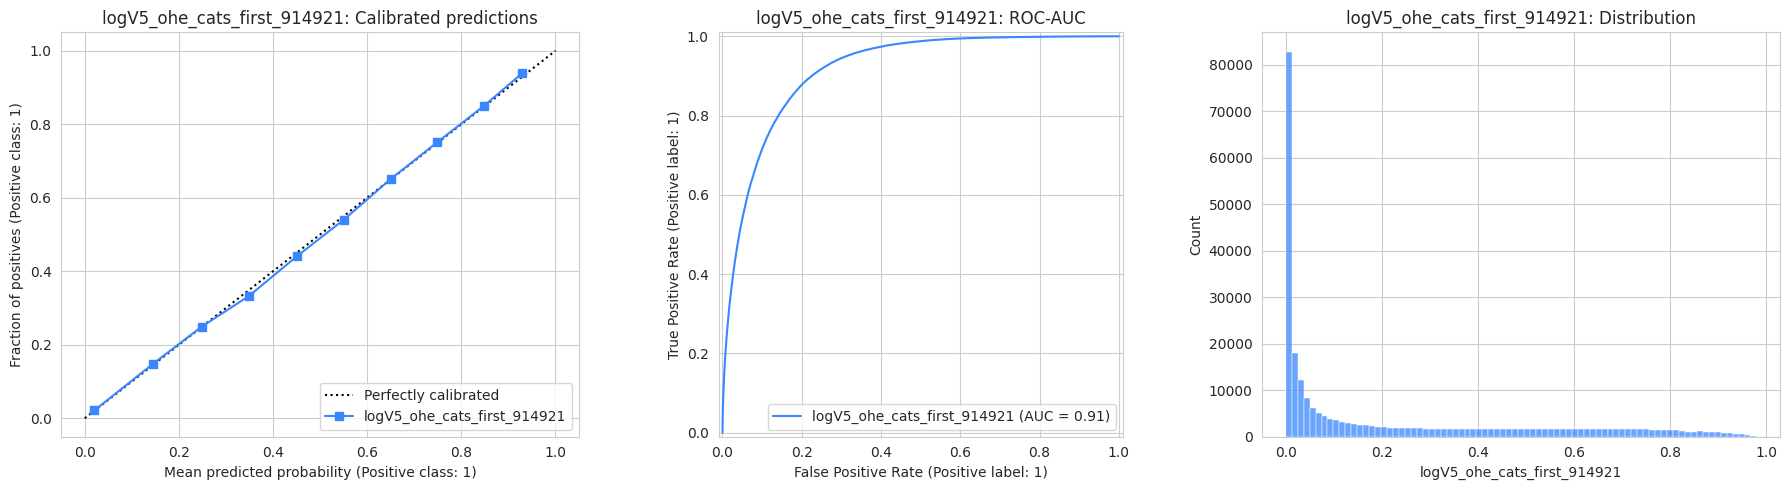

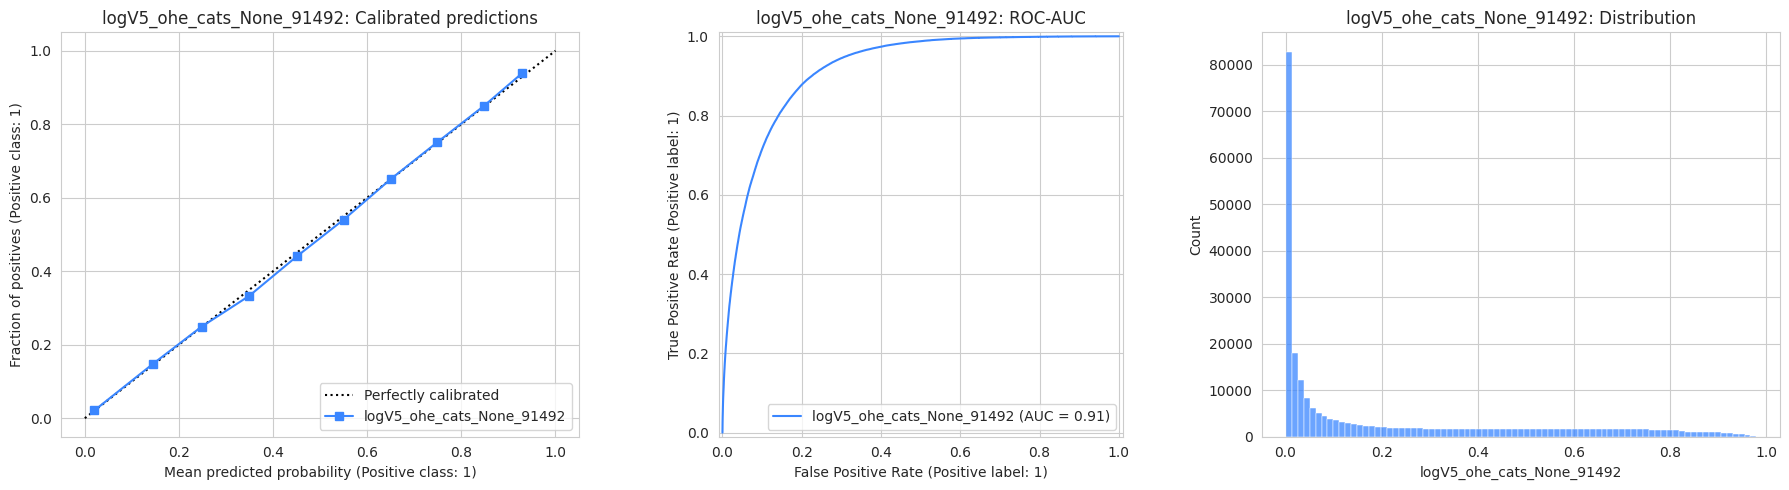

In [35]:
## -- PLOT PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    CalibrationDisplay.from_predictions(train[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibrated predictions")
    
    ## -- ROC curve
    RocCurveDisplay.from_predictions(train[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")
    
    plt.tight_layout()
    plt.show()
    print()

In [36]:
%pip install -U shap
import shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.2 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.50.0
    Uninstalling shap-0.50.0:
      Successfully uninstalled shap-0.50.0
Note: you may need to restart the kernel to use updated packages.


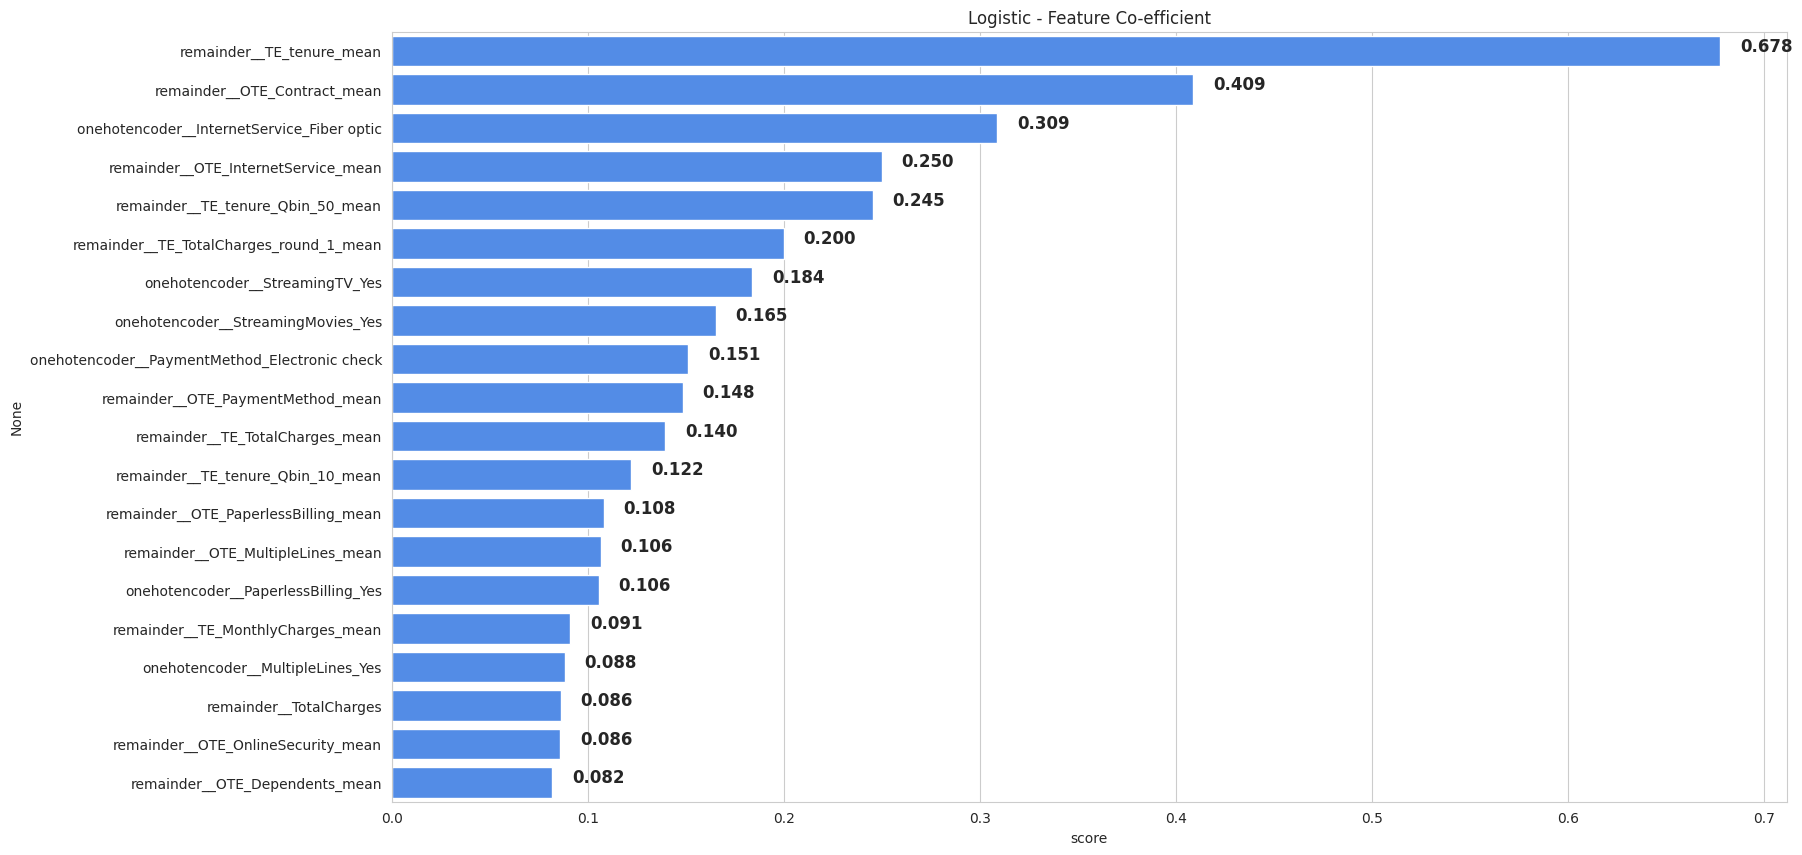

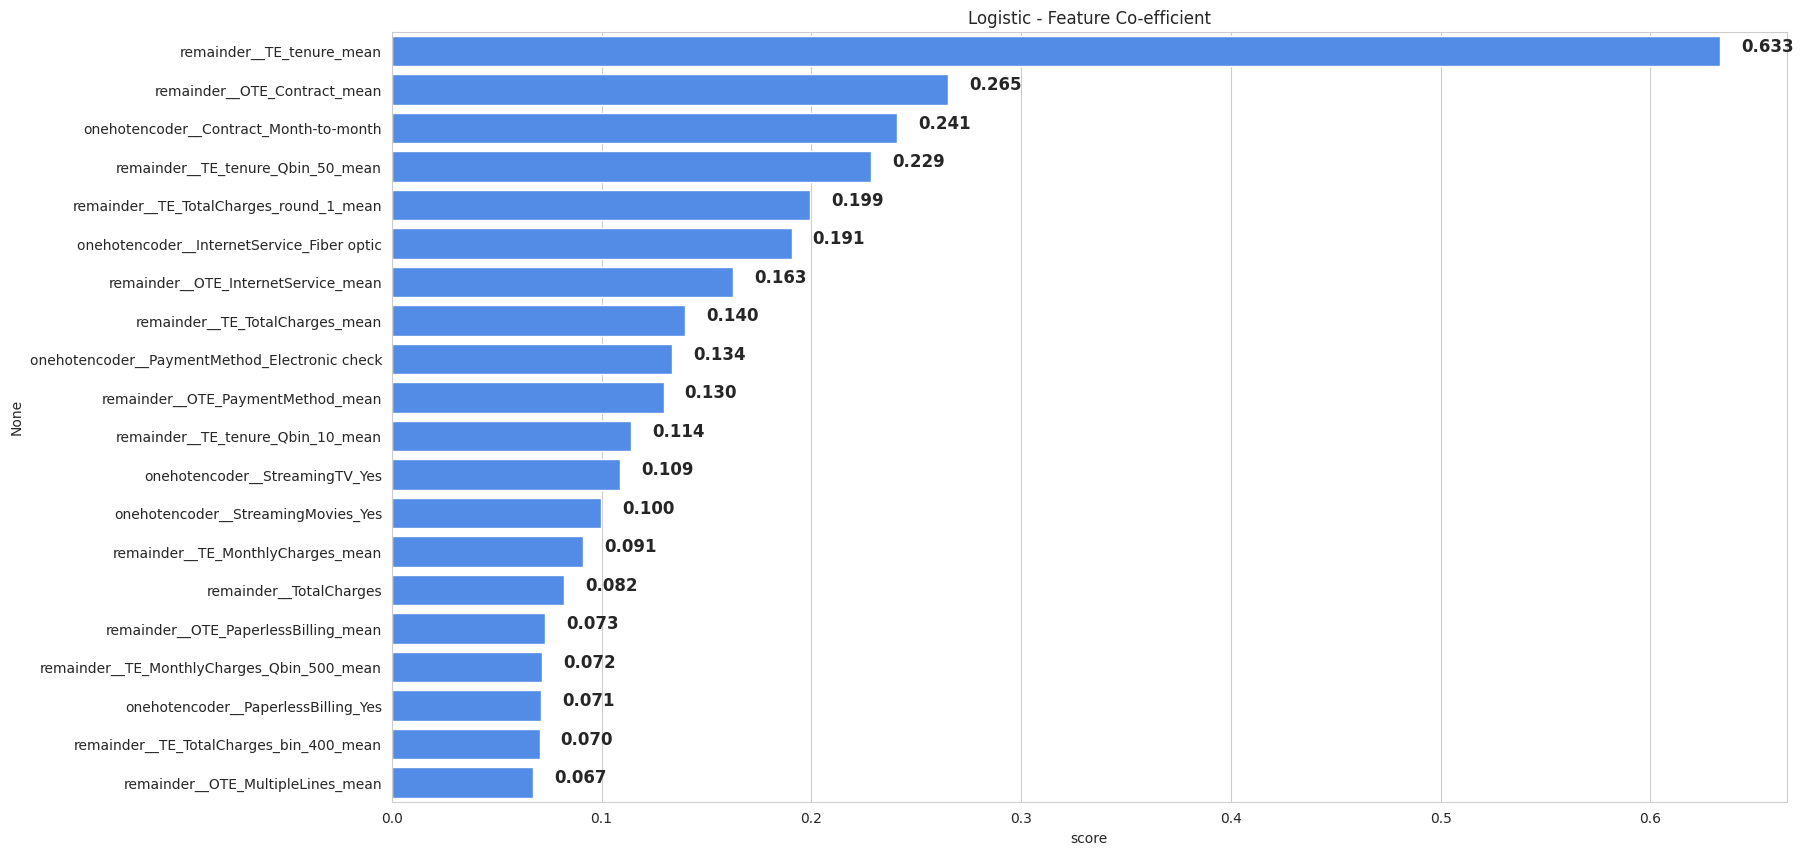

In [37]:
## -- Feature Importances: Linear Model --
m_1 = all_model_predictions[list(all_model_predictions.keys())[0]]
m_2 = all_model_predictions[list(all_model_predictions.keys())[-1]]

for i, m in enumerate([m_1, m_2]): #
    if i >= 0:
        coef_dict = dict(
            zip(
                m['model'][0].get_feature_names_out(),
                m['model'][-1].coef_[0]
            )
        )
        # print(coef_dict)
    
        reg_imp = pd.DataFrame.from_dict(
            coef_dict,
            orient='index',
            columns=['score']
        ).sort_values('score', ascending=False).iloc[:20] # -> Top features
        
        reg_imp.columns = ['score']

        plt.figure(figsize=(18, 10))
        sns.barplot(data=reg_imp, x='score', y=reg_imp.index)
        plt.title('Logistic - Feature Co-efficient')
        
        for i, t in enumerate(reg_imp['score'].values):
            plt.text(t+1e-2, i, f'{t:.3f}', fontdict={'size': 12, 'weight': 'bold'})
        
        # plt.tight_layout()
        plt.show()
        print()

    else:
        coef_dict = dict(zip(m['val_data'].columns.tolist(), m['model'].feature_importances_))
    
        reg_imp = pd.DataFrame.from_dict(
            coef_dict,
            orient='index',
            columns=['score']
        ).sort_values('score', ascending=False).iloc[:20] # -> Top features
        
        reg_imp.columns = ['score']
    
        plt.figure(figsize=(18, 10))
        sns.barplot(data=reg_imp, x='score', y=reg_imp.index)
        plt.title('Random Forest - Feature Importance')
        
        for i, t in enumerate(reg_imp['score'].values):
            plt.text(t+1e-3, i, f'{t:.3f}', fontdict={'size': 12, 'weight': 'bold'})
        
        # plt.tight_layout()
        plt.show()
        print()

In [38]:
# ## -- PLOT SHAP VALUES --
# m_1 = all_model_predictions[list(all_model_predictions.keys())[-1]]
# # m_2 = all_model_predictions[list(all_model_predictions.keys())[-2]]
# # m_3 = all_model_predictions[list(all_model_predictions.keys())[-3]]

# MAX = 15
# for i, m in enumerate([m_1]): # , 
#     ## -- Shap Explainer --
#     explainer = shap.TreeExplainer(m['model'])
#     explanation = explainer(m['val_data'].iloc[:5000])

#     ## -- Bar plot --
#     plt.subplot(121)
#     shap.plots.bar(
#         explanation[0],
#         max_display=MAX,
#         show=False
#     )
#     plt.title('Bar - Overall impact on model predictions')

#     ## -- Beeswarm plot --
#     plt.subplot(122)
#     shap.plots.beeswarm(
#         explanation,
#         max_display=MAX,
#         order=explanation.abs.max(0),
#         color_bar=False,
#         plot_size=(20, 8),
#         show=False,
#     )

#     plt.title('Beeswarm - Most impactful features')
    
#     plt.tight_layout(pad=1.5)
#     plt.show()
#     print()

In [39]:
# ## -- Create Submissions for each model --
# s = str(round(overall_AUC, 5)).split('.')[1]
# np.save(f"oof_log_mdl2_seed{seeding}_{s}.npy", oof_preds)
# np.save(f"pred_log_mdl2_seed{seeding}_{s}.npy", test_preds)
# print(f"{COLOR}✅ oof & prediction files saved!")

# submit[TARGET] = test_preds
# submit.to_csv(f"submit_logistic_OHE_{s}.csv", index=False)

# print(f"{COLOR}✅ submit_logistic_OHE_{s}.csv file saved!")

# HILLCLIMB

In [40]:
# oof_df = pd.DataFrame()
# pred_df = pd.DataFrame()
# print("Loading data: ", end="")
# for (root, dirs, files) in os.walk("/kaggle/working"):
#     for i, file in enumerate(sorted(files), 1):
#         if i%20 == 0: print(f"{i}%.. ", end="")
#         if file.endswith(".npy") and "oof" in file:
#             oof_df = pd.concat([oof_df, pd.Series(np.load(os.path.join(root, file)), name=file[4:-4])], axis=1)
#         elif file.endswith(".npy") and "pred" in file:
#             pred_df = pd.concat([pred_df, pd.Series(np.load(os.path.join(root, file)), name=file[5:-4])], axis=1)

# print(COLOR)
# print(f"Total oof models : {len(oof_df.columns)}")
# print(f"Total pred models: {len(pred_df.columns)}")
# display(oof_df.head())
# display(pred_df.head())

In [41]:
# try:
#     from hillclimbers import climb_hill, partial
# except:
#     !pip install -qq -U hillclimbers
#     from hillclimbers import climb_hill, partial

In [42]:
# %%time
# trn = pd.read_csv(PATH+"train.csv").drop('id', axis=1)
# pred_hc, oof_hc = climb_hill(
#                                train = trn,
#                               target = TARGET,
#                          oof_pred_df = oof_df,
#                         test_pred_df = pred_df,
#                            objective = "maximize",
#                          eval_metric = partial(roc_auc_score),
#                     # negative_weights = True,
#                     return_oof_preds = True,
#                            precision = 0.001,
#                            plot_hill = True,
#                            plot_hist = True,
#     )

In [43]:
# print(f"Hillclimb score: {round(roc_auc_score(train[TARGET], oof_hc), 5)}")
# hc_auc = str(round(roc_auc_score(train[TARGET], oof_hc), 5)).split('.')[1]

In [44]:
# len(oof_hc), len(train[TARGET])

In [45]:
# np.save(f"oof_log-hc_seed{seeding}.npy", oof_hc)
# np.save(f"pred_log-hc_seed{seeding}.npy", pred_hc)

In [46]:
# submit[TARGET] = pred_hc
# submit.to_csv(f"submit_HC-log-seed{seeding}_{hc_auc}.csv", index=False)
# print(f"✅ Saved hillclimb predictions!!!")
# submit.head()

In [47]:
# len(oof_hc), len(pred_hc)